# Entregável 4 — Limpeza e Filtragem Digital dos Sinais

**Disciplina:** Aquisição e Processamento de Biossinais  
**Equipe:** José Ferreira Lessa & Matheus Rocha Gomes da Silva  
**Orientador:** Prof. Dr. Victor Hugo C. de Albuquerque  
**Dataset:** PTB-XL — A Large Publicly Available Electrocardiography Dataset (PhysioNet)  
**Referência:** Wagner et al. (2020). PTB-XL, a large publicly available electrocardiography dataset. *Scientific Data*, 7(1), 154.  
**Data:** Março e Abril de 2026

---

## Objetivo

Este notebook descreve a etapa de **pré-processamento e limpeza dos sinais de ECG**, com foco na remoção controlada de ruídos e artefatos sem comprometer a informação fisiológica relevante. Diferentemente do Entregável 2, onde a qualidade foi apenas avaliada, aqui realizamos uma **intervenção direta nos sinais**, visando torná-los mais adequados para análise estatística e modelagem.

O objetivo central é responder à pergunta: *“como melhorar a qualidade dos sinais mantendo sua integridade clínica?”*.

Para isso, é implementada uma pipeline estruturada e validada, composta pelas seguintes etapas:

1. 

2. **Filtragem no Domínio da Frequência:** aplicação de filtros digitais do tipo Butterworth (passa-alta e passa-baixa) para remoção de drift de baseline e ruído de alta frequência, com análise espectral e validação qualitativa.

3. **Tratamento de Outliers (Winsorização):** controle de valores extremos por derivação utilizando limites baseados no conjunto de treino, evitando *data leakage* e reduzindo o impacto de artefatos impulsivos.

4. **Processamento em Lote:** aplicação consistente da pipeline completa em todos os registros do dataset, com exportação dos sinais limpos em formato NumPy e salvamento dos parâmetros utilizados.

5. **Validação Estatística:** comparação quantitativa entre sinais antes e depois da limpeza por meio de testes estatísticos (Wilcoxon pareado) e medidas de tamanho de efeito (Cohen’s d), avaliando a seletividade da pipeline.
**Reavaliação da Qualidade (SQI):** recálculo das métricas de qualidade e reclassificação dos sinais, permitindo analisar o impacto global da pipeline nas classes de qualidade (G, A, P e U).

6. **Síntese e Conexão:**

> **Nota metodológica:** Diferentemente da etapa de avaliação de qualidade (Entregável 2), esta etapa realiza transformações ativas nos sinais. Ainda assim, todas as decisões (limiares, métricas e critérios de avaliação) são mantidas consistentes, garantindo comparabilidade direta entre os estados *antes* e *depois*.

Ao final, obtém-se um dataset de sinais limpos, estatisticamente validados e prontos para as etapas seguintes do pipeline, especialmente **segmentação e extração de características**, que serão abordadas no Entregável 5.



## 1. Importações, Configurações e Dependências

Bibliotecas já utilizadas em Entregáveis anteriores:

- `os` para manipulação de diretórios e caminhos de arquivos.  
- `ast` para conversão segura de strings em estruturas Python (listas, dicionários, etc.).  
- `numpy` para operações numéricas e manipulação de arrays.  
- `pandas` para manipulação e análise de dados estruturados.  
- `matplotlib.pyplot` e `seaborn` para visualizações gráficas.  
- `wfdb` para leitura e processamento de sinais fisiológicos no formato PhysioNet.  
- `scipy.signal` para análise e processamento de sinais (ex: filtros digitais e análise espectral).  
- `scipy.stats` para cálculo de métricas estatísticas e aplicação de testes (ex: skewness, kurtosis e testes de hipótese).  
- `pathlib.Path` para manipulação de caminhos de arquivos de forma segura e multiplataforma.  
- `tqdm` para exibição de barras de progresso em loops, útil no processamento de grandes volumes de sinais.  
- `IPython.display` para exibição formatada de saídas em notebooks (como Markdown).  
- `warnings` para controle e supressão de avisos durante a execução.  

### Novas dependências adicionadas neste entregável

- `joblib` para **serialização eficiente de objetos Python**, sendo utilizado para salvar parâmetros da pipeline (ex: filtros e limites de winsorização), garantindo reprodutibilidade e evitando recomputações desnecessárias.  

- `sys` para **manipulação dinâmica do caminho de importação (`sys.path`)**, permitindo reutilizar código desenvolvido em outros entregáveis (neste caso, as funções de cálculo e classificação de SQI).  

- Módulo local `sqi_utils` (do Entregável 2), importado via caminho relativo, contendo:
  - `compute_all_sqi`: cálculo completo das métricas de qualidade de sinal  
  - `classify_sqi`: classificação final dos sinais em G, A, P ou U  

Essa abordagem modular permite:

- reutilização de código validado previamente  
- consistência metodológica entre os entregáveis  
- separação clara entre cálculo de métricas e aplicação da pipeline  

In [1]:
import os
import ast
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import scipy.signal as signal
import scipy.stats as stats 
from pathlib import Path              
from tqdm import tqdm
from IPython.display import display, Markdown
import warnings
import sys

sqi_path = Path('../../entregavel-2/notebooks').resolve()
sys.path.append(str(sqi_path))

from sqi_utils import compute_all_sqi, classify_sqi

warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)

## 2. Configurações Globais

In [2]:
DATA_DIR = Path('../../../data/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/')
FS = 100
N_LEADS = 12
LEAD_NAMES = ['I', 'II', 'III', 'aVL', 'aVR', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
FOLDS_TREINO = [1, 2, 3, 4, 5, 6, 7, 8]
FOLD_VAL = 9
FOLD_TEST = 10

FIGS_DIR = Path('../figuras')
OUT_DIR  = Path('../outputs')
for d in [FIGS_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print('Configuração concluída.')
print(f'Figuras em : {FIGS_DIR.resolve()}')
print(f'Outputs em : {OUT_DIR.resolve()}')

Configuração concluída.
Figuras em : C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-4\figuras
Outputs em : C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-4\outputs


## 3. Carregamento e Filtragem por SQI
Trabalhamos apenas com registros Categoria G, A (aprovados no Entregável 2) e P (aprovados, desde que limpos).

In [3]:
caminho_metadados = Path('../../entregavel-2/outputs/ptbxl_com_sqi.csv').resolve()

if not os.path.exists(caminho_metadados):
    raise FileNotFoundError("Arquivo ptbxl_com_sqi.csv não encontrado. Execute o Entregável 2 primeiro.")

df = pd.read_csv(caminho_metadados, index_col='ecg_id')
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)
df['superclasses_clean'] = df['superclasses_clean'].apply(ast.literal_eval)

df = df[df['quality_class'].isin(['G', 'A', 'P'])].copy()

display(Markdown(f"Registros carregados: **{len(df)}** (Categorias G, A ou P)."))

Registros carregados: **19840** (Categorias G, A ou P).

## Função para carregar ECG Bruto

Mesma função já definida em entregáveis anteriores, responsável por carregar os sinais de forma computável pelo restante do pipeline.

In [4]:
def load_ecg_raw(eid):
    """
    Carrega sinal ECG (12 derivações) a partir do ecg_id usando wfdb.
    Retorna array numpy (N_amostras x 12).
    """
    row = df.loc[eid]
    path = DATA_DIR / row['filename_lr']  # versão 100 Hz
    signal_data, _ = wfdb.rdsamp(str(path))
    return signal_data

---

## Seção 1 — Inventário de Problemas e Plano de Ação

Esta seção estabelece o **diagnóstico técnico dos sinais de ECG** e define o **plano de limpeza e filtragem** que será implementado nas etapas seguintes.

A construção desse plano é baseada diretamente nos resultados obtidos nos entregáveis anteriores:

- **Entregável 2 (SQI):** identificação de artefatos e degradações de qualidade do sinal  
- **Entregável 3 (Análise Estatística):** caracterização das distribuições, presença de outliers, assimetrias e instabilidade de variância  

A integração dessas duas análises permite responder de forma objetiva:

> **Quais problemas afetam os sinais e quais deles podem ser corrigidos por processamento digital?**

---

### Natureza dos problemas identificados

Os artefatos observados nos sinais podem ser divididos em dois grandes grupos:

- **Problemas estruturais severos**  
  Comprometem a integridade do sinal (ex: trechos mortos, ruído extremo)  
  → Já tratados por exclusão no SQI (classe U)

- **Problemas corrigíveis**  
  Afetam parcialmente o sinal, mas preservam informação fisiológica relevante  
  → Podem ser tratados via filtragem digital e técnicas robustas  

É importante destacar que:

> A presença de artefatos não está restrita à classe P — sinais considerados aceitáveis (classe A) também podem apresentar distorções relevantes do ponto de vista estatístico.

---

### Objetivo da seção

A partir desse diagnóstico, esta seção tem como objetivo:

- Identificar os **principais tipos de artefatos presentes nos sinais**  
- Estabelecer um **mapeamento entre problema e técnica de correção**  
- Definir **parâmetros técnicos explícitos** para cada método adotado  

Esse mapeamento servirá como base para:

- A implementação dos filtros digitais (Seção 2)  
- O tratamento de outliers (Seção 3)  
- A validação quantitativa dos efeitos da limpeza (Seção 4)  

---

### Limitação fundamental

Nem todos os problemas identificados são totalmente corrigíveis.

Em particular:

- Artefatos associados à **distorção morfológica do sinal** (ex: baixo hosSQI)  
  não possuem correção direta via filtragem clássica  

Assim, o objetivo do processo de limpeza não é “perfeição”, mas:

> **Melhorar a qualidade do sinal e a estabilidade estatística, preservando sua estrutura fisiológica essencial**

---

### 1.1 Quadro de Problemas e Técnicas

A partir dos diagnósticos obtidos nos entregáveis anteriores, foi possível identificar um conjunto consistente de **artefatos recorrentes nos sinais de ECG**, bem como sua relação com métricas de qualidade (SQI) e propriedades estatísticas (Seção 3).

Com base nisso, estabelecemos um mapeamento direto entre:

> **Problema observado → Evidência → Técnica de correção → Parâmetros adotados**

---

### Quadro de referência

| Problema | Origem / Evidência | Técnica de Correção | Parâmetros |
|---|---|---|---|
| Interferência de rede (50 Hz) | Ruído senoidal típico; não observado de forma significativa devido à baixa taxa de amostragem | Não aplicável | Limitação de Nyquist (fs = 100 Hz) |
| Drift de linha de base | Baixo *basSQI*, variações lentas (respiração, movimento, eletrodos) | Filtro passa-alta Butterworth | fc = 0.5 Hz, ordem = 5 |
| Ruído de alta frequência (> 40 Hz) | Baixo SNR, alta entropia espectral | Filtro passa-baixa Butterworth | fc = 40 Hz, ordem = 5 |
| Outliers de amplitude | Caudas pesadas, alta kurtosis e valores extremos (Seção 3) | Winsorização por percentil | 0.5% – 99.5% (por derivação) |
| Distorções morfológicas (hosSQI baixo) | Forma anômala do sinal, ruído impulsivo ou irregularidades estruturais | Atenuação indireta (filtragem + métodos robustos) | Não parametrizável diretamente |

---

### Interpretação técnica

A escolha das técnicas segue princípios clássicos de processamento de sinais biomédicos:

- O uso combinado de filtros passa-alta e passa-baixa define um:

  **intervalo de interesse fisiológico (~0.5–40 Hz)**  
  onde se concentra a maior parte da informação relevante do ECG  

- O filtro passa-alta remove componentes de **baixa frequência não fisiológica**, como:
  - drift de linha de base  
  - movimentação do paciente  

- O filtro passa-baixa reduz:
  - ruído muscular (EMG)  
  - interferências elétricas de alta frequência  

- A winsorização atua em um nível diferente:
  - não altera o sinal no domínio da frequência  
  - reduz o impacto de **valores extremos**, estabilizando métricas como média, variância e kurtosis  

---

### Limitação das técnicas

Nem todos os artefatos possuem solução direta.

Em especial:

- Distorções capturadas por métricas como *hosSQI* refletem **alterações na forma do sinal**, que podem ter origem em:
  - ruído impulsivo  
  - falhas de aquisição  
  - alterações clínicas reais  

Nesses casos:

> A estratégia não é corrigir completamente, mas **reduzir o impacto estatístico e melhorar a interpretabilidade**

---

### Síntese do plano

O plano de limpeza adotado combina duas abordagens complementares:

- **Filtragem no domínio da frequência** → remoção de ruídos estruturais  
- **Tratamento estatístico robusto** → controle de outliers e caudas pesadas  

Essa combinação permite atuar simultaneamente sobre:

- a **qualidade física do sinal**
- e a **estabilidade estatística das métricas extraídas**

garantindo consistência para as análises subsequentes.

---


## Seção 2 — Implementação dos Filtros Digitais

Esta seção descreve a implementação dos filtros digitais definidos no plano de ação (Seção 1), com o objetivo de remover artefatos no domínio da frequência e estabilizar o sinal de ECG para análises posteriores.

O princípio central adotado é:

> Atenuar componentes não fisiológicos do sinal, preservando a morfologia das ondas cardíacas (P-QRS-T)

Todos os filtros foram aplicados utilizando filtragem bidirecional (`filtfilt`), eliminando defasagem de fase e garantindo preservação temporal das características do sinal.


### 2.1 Estratégia de Filtragem

Com base no inventário de problemas, a filtragem foi estruturada em duas etapas principais:

- Remoção de componentes de baixa frequência (drift de linha de base)
- Atenuação de componentes de alta frequência (ruído muscular e interferências)

Essa abordagem define implicitamente um filtro passa-faixa no intervalo:

> 0.5 Hz $\leq$ f $\leq$ 40 Hz

Este intervalo concentra a maior parte da informação fisiologicamente relevante do ECG clínico.

### 2.2 Escolha do Modelo de Filtro

Os filtros foram implementados utilizando o modelo **Butterworth**, escolhido pelas seguintes propriedades:

- Resposta em frequência maximamente plana na banda passante
- Ausência de ondulações (ripple)
- Boa estabilidade numérica
- Ampla utilização em processamento de sinais biomédicos

A resposta em magnitude de um filtro Butterworth de ordem \( n \) é dada por:

$\Large |H(j\omega)|^2 = \frac{1}{1 + \left(\frac{\omega}{\omega_c}\right)^{2n}}$

em que $\omega_c$ representa a frequência de corte.


### 2.3 Justificativa dos Parâmetros

Os parâmetros adotados seguem práticas consolidadas na literatura de ECG:

- **Filtro passa-alta**
  - Frequência de corte: 0.5 Hz  
  - Remove variações lentas associadas à respiração, movimento e contato de eletrodos  

- **Filtro passa-baixa**
  - Frequência de corte: 40 Hz  
  - Remove ruído muscular (EMG) e interferências de alta frequência  

- **Ordem do filtro: 5**
  - Compromisso entre seletividade espectral e estabilidade numérica  
  - Ordens mais altas aumentam distorções e instabilidade  
  - Ordens mais baixas reduzem a eficácia da filtragem  


### 2.4 Interferência de Rede (50 Hz) e Limitação de Nyquist

A interferência de rede elétrica (50 Hz) é um artefato clássico em sinais biomédicos e, em condições normais, seria tratada com um filtro notch.

No entanto, para sinais com frequência de amostragem de 100 Hz:

- Frequência de Nyquist: 50 Hz  
- A frequência de interferência coincide exatamente com o limite espectral representável  

Isso implica que:

> Não é possível projetar um filtro notch estável e robusto exatamente em 50 Hz nesse contexto

Além disso, o dataset utilizado (PTB-XL) na versão de 100 Hz foi obtido por decimação de sinais originalmente amostrados a 500 Hz.

Esse processo envolve necessariamente um filtro anti-aliasing, que já remove componentes próximas ou acima da frequência de Nyquist.

Portanto:

> A interferência de 50 Hz já foi efetivamente atenuada durante o processo de downsampling, não sendo necessária filtragem adicional nesta etapa

### 2.5 Implementação Computacional

A implementação foi realizada em Python utilizando o módulo `scipy.signal`.

In [5]:
# Definição dos Filtros

def get_bandpass_filters(fs, lowcut=0.5, highcut=40.0, order=5):
    nyq = 0.5 * fs
    b_high, a_high = signal.butter(order, lowcut / nyq, btype='highpass')
    b_low, a_low = signal.butter(order, highcut / nyq, btype='lowpass')
    return (b_high, a_high), (b_low, a_low)

def preprocess_signal(sig):
    (bh, ah), (bl, al) = get_bandpass_filters(FS)

    # 1. Remoção de baseline
    s1 = signal.filtfilt(bh, ah, sig, axis=0)

    # 2. Remoção de alta frequência
    s2 = signal.filtfilt(bl, al, s1, axis=0)

    return s2

### 2.6 Validação Espectral e no Domínio do Tempo

#### Verificação da ausência de componente em 50 Hz

A análise espectral foi utilizada para verificar empiricamente a presença de interferência de rede elétrica (50 Hz) nos sinais.

Considerando que:

- A frequência de Nyquist para fs = 100 Hz é 50 Hz  
- O dataset foi obtido por decimação com filtragem anti-aliasing  

espera-se ausência de energia significativa nessa frequência.

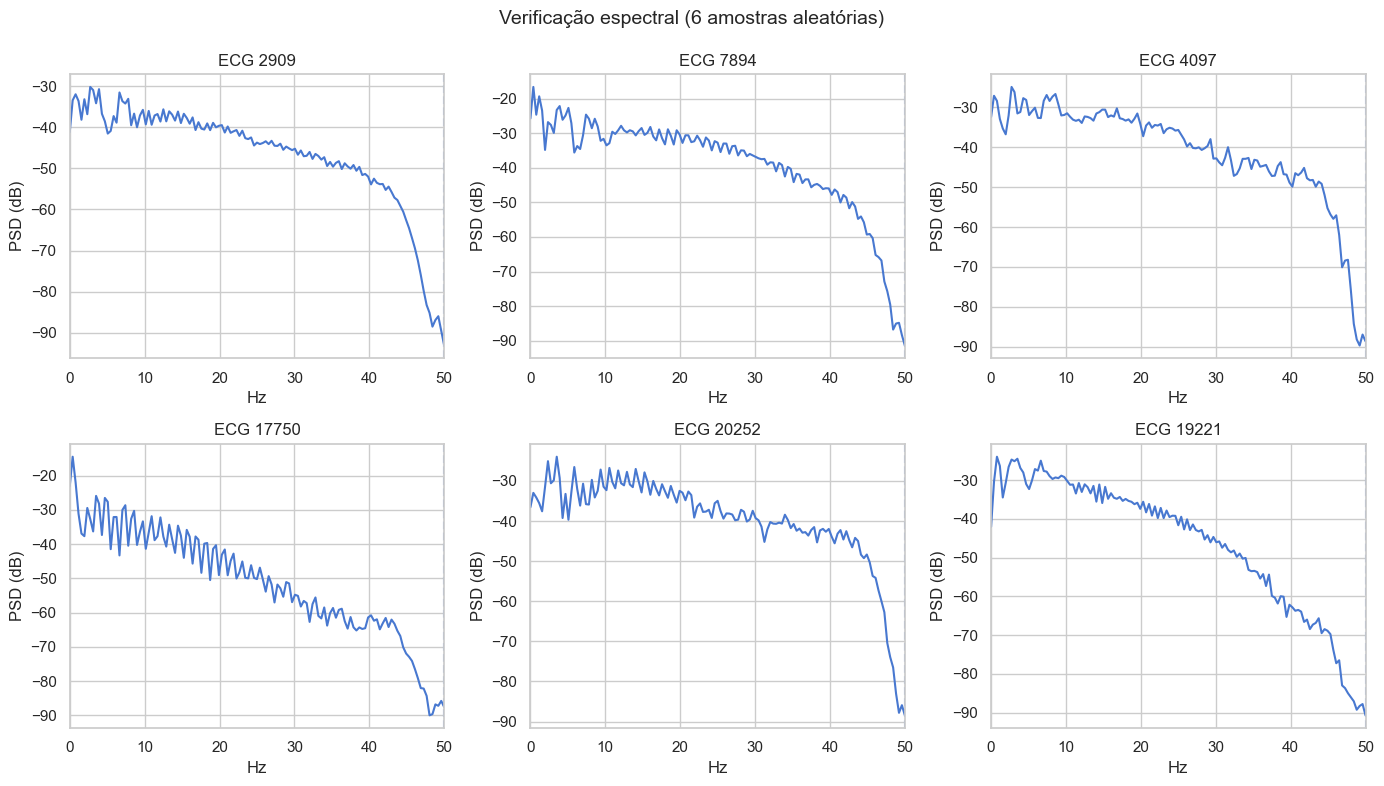

In [6]:
# Seleciona 6 amostras aleatórias para verificar seus aspectos de potência

amostras = df.sample(6, random_state=42).index

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eid in enumerate(amostras):
    ax = axes[i]
    
    sig = load_ecg_raw(eid)
    
    # Derivação II (índice 1)
    f, pxx = signal.welch(sig[:, 1], fs=FS, nperseg=256)
    
    ax.plot(f, 10 * np.log10(pxx + 1e-10))
    ax.axvline(50, linestyle='--', alpha=0.7)
    
    ax.set_xlim(0, FS / 2)
    ax.set_title(f'ECG {eid}')
    ax.set_xlabel('Hz')
    ax.set_ylabel('PSD (dB)')

# Ajustes finais
plt.suptitle('Verificação espectral (6 amostras aleatórias)', fontsize=14)
plt.tight_layout()

# Ajuste para não sobrepor o título
plt.subplots_adjust(top=0.9)

plt.savefig(FIGS_DIR / 'verificacao_50hz.png', dpi=150)
plt.show()

Os resultados confirmam essa hipótese, indicando que a interferência de rede já foi atenuada durante o pré-processamento original do dataset.

#### Correção de baseline e ruído de alta frequência

A aplicação do pipeline de filtragem (passa-alta seguido de passa-baixa) foi avaliada no domínio do tempo em um conjunto de seis amostras aleatórias do dataset.

A comparação entre os sinais originais e filtrados, organizada em um grid 2×3, evidencia de forma consistente:

- Estabilização da linha de base em torno de 0 mV  
- Redução significativa de componentes de alta frequência  
- Preservação da morfologia das ondas P-QRS-T em diferentes registros  

A repetição desse comportamento em múltiplas amostras reforça a robustez da abordagem, indicando que a filtragem é eficaz sem comprometer a estrutura fisiológica essencial do sinal.

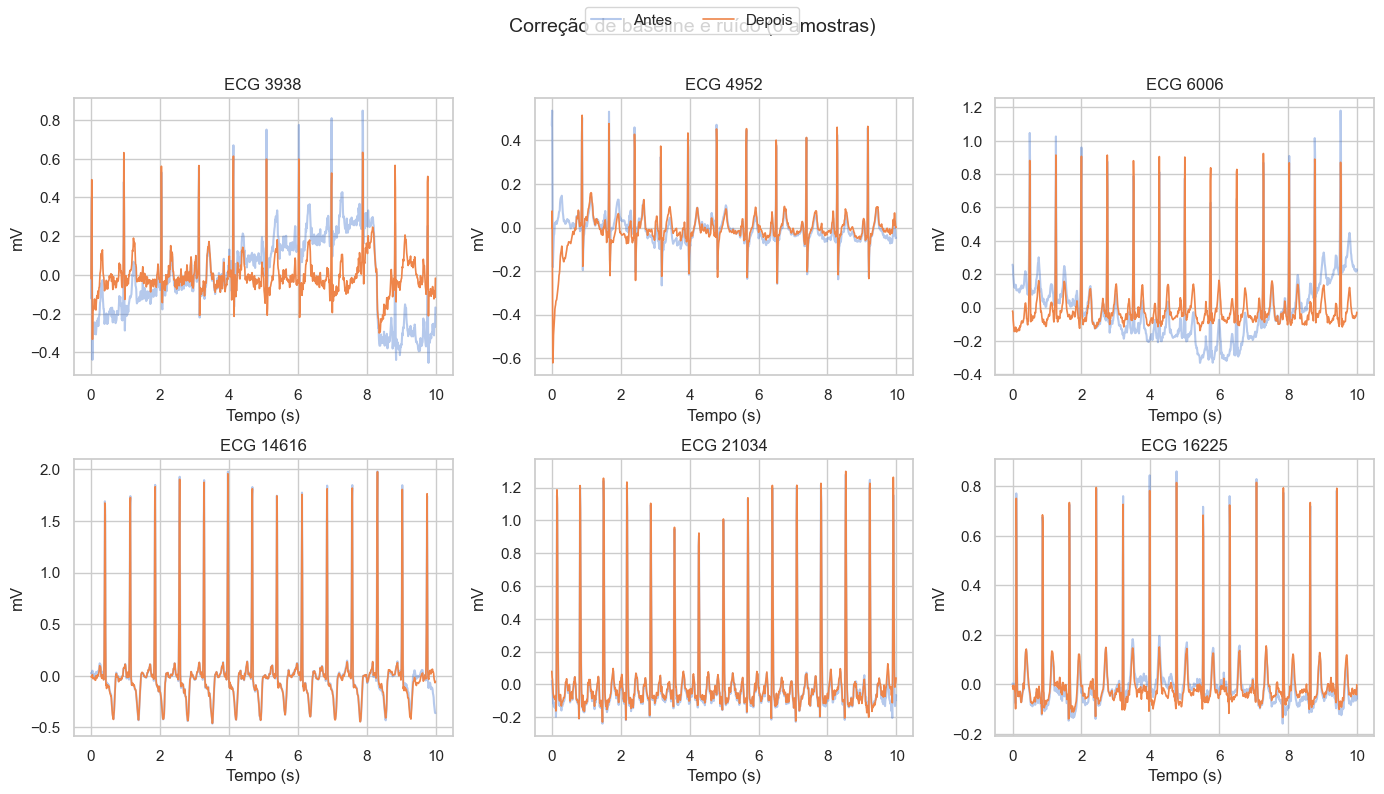

In [7]:
# Seleciona 6 amostras aleatórias para serem processadas com os filtros de frequência e visualmente comparadas com suas originais
amostras = df.sample(6, random_state=67).index

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eid in enumerate(amostras):
    ax = axes[i]
    
    raw = load_ecg_raw(eid)
    clean = preprocess_signal(raw)
    
    t = np.arange(len(raw)) / FS
    
    # Plot (derivação I)
    ax.plot(t, raw[:, 0], alpha=0.4, label='Antes')
    ax.plot(t, clean[:, 0], linewidth=1.2, label='Depois')
    
    ax.set_title(f'ECG {eid}')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('mV')

# Legenda única
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)

plt.suptitle('Correção de baseline e ruído (6 amostras)', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.88)

plt.savefig(FIGS_DIR / 'correcao_baseline_hf.png', dpi=150)
plt.show()

### 2.7 Espectro Médio do Dataset

A avaliação no domínio da frequência foi conduzida em duas frentes complementares:

- **Análise individual (6 amostras):** visualização comparativa antes vs depois em um grid 2×3  
- **Análise global (100 registros):** cálculo do espectro médio do dataset  

Nas análises individuais, observa-se de forma consistente:

- Redução de energia em baixas frequências (< 0.5 Hz)  
- Atenuação de componentes de alta frequência (> 40 Hz)  
- Manutenção do conteúdo espectral intermediário  

Já o espectro médio confirma quantitativamente esse comportamento, evidenciando:

- Atenuação sistemática das componentes fora da banda de interesse  
- Preservação de um platô espectral na faixa 0.5–40 Hz  

Em conjunto, esses resultados demonstram que o pipeline atua de forma consistente tanto em nível individual quanto global, validando sua efetividade no domínio da frequência.

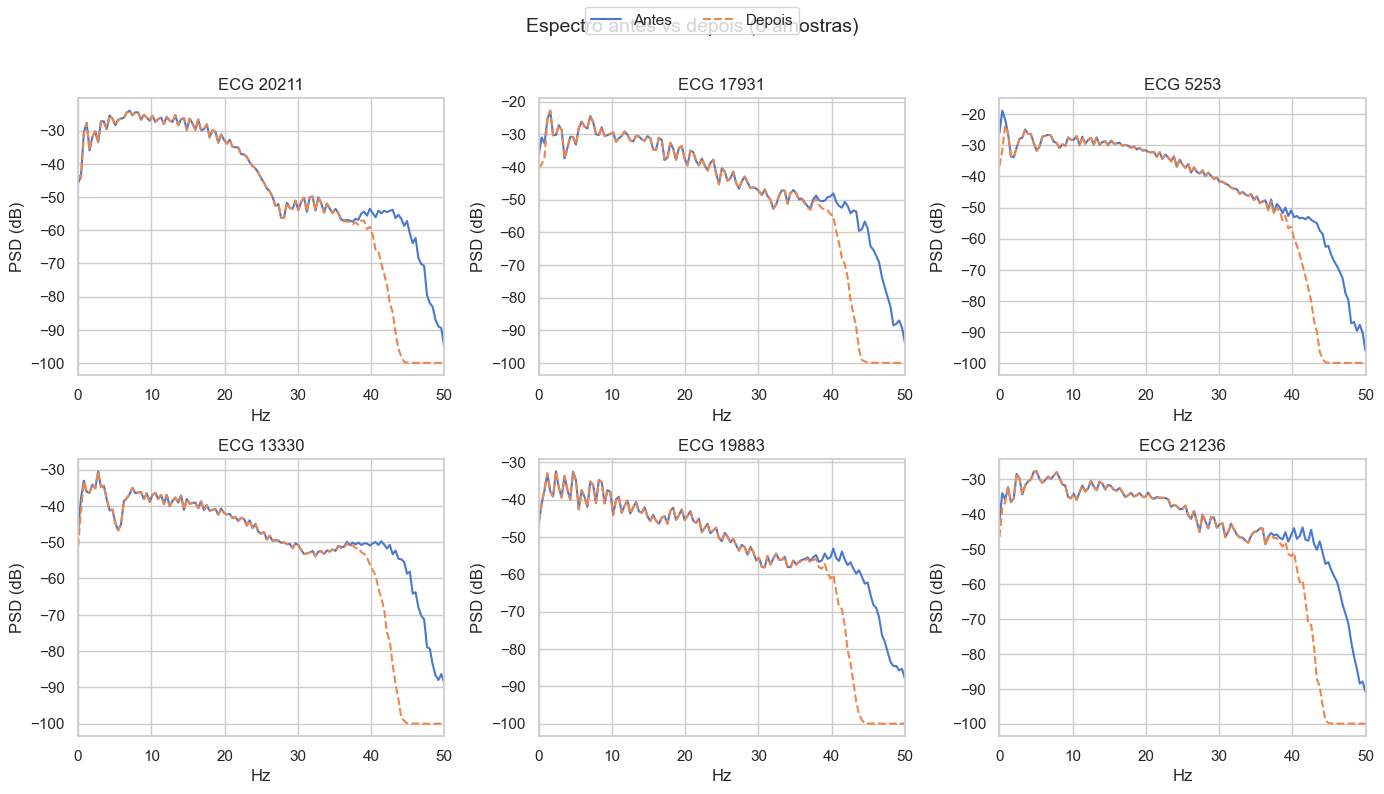

In [8]:
# Seleciona 6 amostras para terem seus aspectros de potência amostrados antes e depois dos filtros implementados
amostras = df.sample(6, random_state=456).index

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eid in enumerate(amostras):
    ax = axes[i]
    
    raw = load_ecg_raw(eid)
    clean = preprocess_signal(raw)
    
    # Derivação II (mais estável)
    f, p_raw = signal.welch(raw[:, 1], fs=FS, nperseg=256)
    _, p_clean = signal.welch(clean[:, 1], fs=FS, nperseg=256)
    
    ax.plot(f, 10 * np.log10(p_raw + 1e-10), label='Antes')
    ax.plot(f, 10 * np.log10(p_clean + 1e-10), linestyle='--', label='Depois')
    
    ax.set_xlim(0, FS / 2)
    ax.set_title(f'ECG {eid}')
    ax.set_xlabel('Hz')
    ax.set_ylabel('PSD (dB)')

# Legenda global
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)

plt.suptitle('Espectro antes vs depois (6 amostras)', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.88)

plt.savefig(FIGS_DIR / 'espectro.png', dpi=150)
plt.show()

Calculando espectros médios: 100%|██████████| 100/100 [00:01<00:00, 61.81it/s]


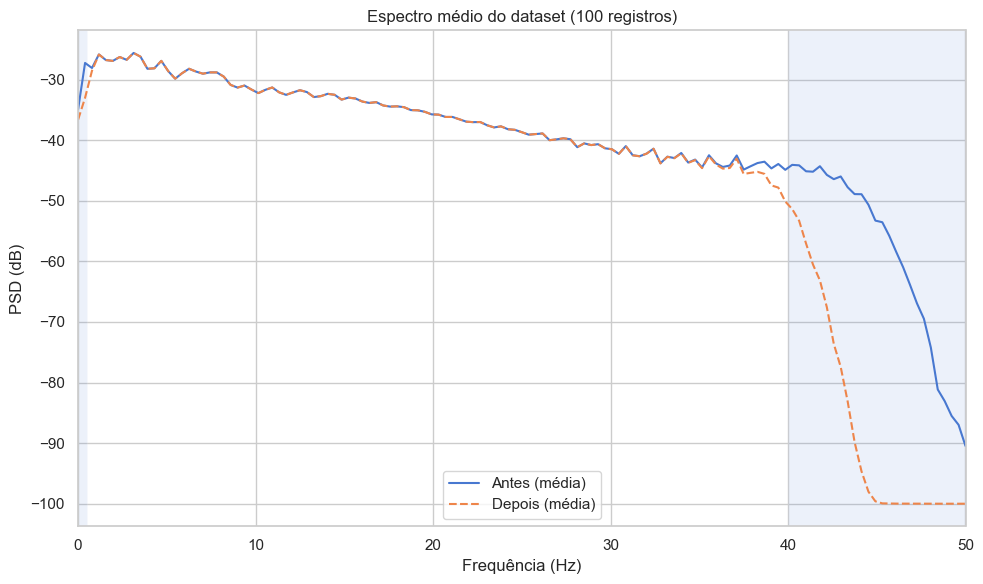

In [9]:
# Subamostragem de 100 sinais diferentes, efetuando a média do mesmo exemplo executado acima
amostra_esp = df.sample(100, random_state=42).index

psds_antes = []
psds_depois = []

for eid in tqdm(amostra_esp, desc='Calculando espectros médios'):
    sig_raw = load_ecg_raw(eid)
    sig_clean = preprocess_signal(sig_raw)

    f, p_raw = signal.welch(sig_raw[:, 1], fs=FS, nperseg=256)
    _, p_clean = signal.welch(sig_clean[:, 1], fs=FS, nperseg=256)

    psds_antes.append(p_raw)
    psds_depois.append(p_clean)

psd_media_antes = 10 * np.log10(np.mean(psds_antes, axis=0) + 1e-10)
psd_media_depois = 10 * np.log10(np.mean(psds_depois, axis=0) + 1e-10)

plt.figure()

plt.plot(f, psd_media_antes, label='Antes (média)')
plt.plot(f, psd_media_depois, linestyle='--', label='Depois (média)')

# Regiões removidas
plt.axvspan(0, 0.5, alpha=0.1)
plt.axvspan(40, 50, alpha=0.1)

plt.xlim(0, FS / 2)
plt.xlabel('Frequência (Hz)')
plt.ylabel('PSD (dB)')
plt.title('Espectro médio do dataset (100 registros)')
plt.legend()

plt.tight_layout()
plt.savefig(FIGS_DIR / 'espectro_medio.png', dpi=150)
plt.show()

### 2.8 Limitações

Apesar dos resultados consistentes observados em múltiplas amostras, a filtragem apresenta limitações importantes:

- Não corrige distorções morfológicas complexas (ex: baixo hosSQI)  
- Pode introduzir pequenas alterações de amplitude ou suavização de picos  
- Depende da escolha adequada dos parâmetros (frequências de corte e ordem do filtro)  

Além disso, por atuar no domínio da frequência, a filtragem não é capaz de distinguir entre:

- ruído não fisiológico  
- variações clínicas legítimas do sinal  

Dessa forma, esta etapa deve ser interpretada como:

> Um processo de melhoria da qualidade do sinal, e não de reconstrução perfeita

---


## Seção 3 — Tratamento de Outliers e Atenuação de Distorções Morfológicas

Esta seção aborda o tratamento de **valores extremos (outliers)** e a atenuação indireta de **distorções morfológicas** nos sinais de ECG.

Diferentemente da filtragem (Seção 2), que atua no domínio da frequência, as técnicas aqui aplicadas operam diretamente no domínio da amplitude, com foco em:

- estabilização estatística  
- redução de caudas pesadas  
- mitigação de artefatos impulsivos  

### 3.1 Estratégia de Tratamento

O tratamento adotado combina duas abordagens complementares:

- **Winsorização por percentil** → controle de outliers de amplitude  
- **Atenuação indireta de distorções morfológicas** → via robustez estatística  

Essa abordagem é motivada pelas análises da Seção 1, que indicaram:

- presença de distribuições com alta kurtosis  
- ocorrência de valores extremos  
- sinais com baixo *hosSQI*, indicando distorções morfológicas  

### 3.2 Winsorização por Percentil

A winsorização consiste em limitar os valores do sinal a um intervalo definido por percentis da distribuição, substituindo valores extremos pelos limites estabelecidos.

Diferentemente da remoção de outliers, essa abordagem:

- preserva o número de amostras  
- mantém a estrutura temporal do sinal  
- reduz o impacto de valores extremos em métricas estatísticas  

### 3.3 Definição dos Limites (Treino)

Para evitar **data leakage**, os limites de winsorização foram calculados exclusivamente a partir dos dados de treino (folds 1–8).

O procedimento adotado foi:

- Amostragem de até 2500 sinais do conjunto de treino  
- Aplicação prévia do pipeline de filtragem (Seção 2)  
- Agregação dos valores por derivação  
- Cálculo dos percentis 0.5% e 99.5%  

Os limites são definidos **individualmente por derivação**, respeitando as diferenças fisiológicas entre canais.

In [10]:
# Extração de amostras para estimativa robusta dos percentis

df_treinos = df[df['strat_fold'].isin(FOLDS_TREINO)]

amostra_treino = df_treinos.sample(
    n=min(2500, len(df_treinos)),
    random_state=42
).index.tolist()

distribuicao_por_lead = {i: [] for i in range(N_LEADS)}

for eid in tqdm(amostra_treino, desc='Calculando percentis de treino'):
    sig = preprocess_signal(load_ecg_raw(eid))
    
    for i in range(N_LEADS):
        distribuicao_por_lead[i].append(sig[:, i])

# --- Resumo informativo ---
total_sinais = len(amostra_treino)
total_amostras = sum(len(np.concatenate(distribuicao_por_lead[i])) for i in range(N_LEADS))

display(Markdown(f"""
**Resumo da amostragem para winsorização:**
- Sinais utilizados: **{total_sinais}**
- Derivações analisadas: **{N_LEADS}**
- Total de pontos agregados: **{total_amostras:,}**
"""))

Calculando percentis de treino:   0%|          | 0/2500 [00:00<?, ?it/s]

Calculando percentis de treino: 100%|██████████| 2500/2500 [00:34<00:00, 72.80it/s]



**Resumo da amostragem para winsorização:**
- Sinais utilizados: **2500**
- Derivações analisadas: **12**
- Total de pontos agregados: **30,000,000**


In [11]:
# Cálculo dos percentis

lower_bounds = []
upper_bounds = []

for i in range(N_LEADS):
    arr = np.concatenate(distribuicao_por_lead[i])
    
    lower_bounds.append(np.percentile(arr, 0.5))
    upper_bounds.append(np.percentile(arr, 99.5))

limites_treino = {
    'lower_bounds': lower_bounds,
    'upper_bounds': upper_bounds
}

In [12]:
# Tabela de limites

df_limites = pd.DataFrame({
    'Derivação': LEAD_NAMES,
    'Limite inferior (0.5%)': [f"{v:.4f}" for v in lower_bounds],
    'Limite superior (99.5%)': [f"{v:.4f}" for v in upper_bounds]
})

display(df_limites)

,Derivação,Limite inferior (0.5%),Limite superior (99.5%)
0,I,-0.3061,0.9037
1,II,-0.4319,0.8363
2,III,-0.7993,0.5091
3,aVL,-0.7726,0.2752
4,aVR,-0.3270,0.7728
5,aVF,-0.5325,0.5967
6,V1,-1.2294,0.5791
7,V2,-1.8212,0.9798
8,V3,-1.5736,1.1757
9,V4,-1.0508,1.4859


### 3.4 Aplicação da Winsorização

A winsorização é aplicada após a filtragem, utilizando os limites calculados no conjunto de treino.

Para cada derivação:

- valores abaixo do percentil 0.5% são elevados ao limite inferior  
- valores acima do percentil 99.5% são reduzidos ao limite superior  

Esse processo reduz a influência de:

- picos espúrios  
- artefatos impulsivos  
- saturações de sinal  

A seguir, apresenta-se a função utilizada para aplicação da winsorização:

In [13]:
# Função de Winsorização

def winsorizar(sig, bounds_dict):
    """
    Aplica winsorização por derivação usando limites do treino.
    """
    out = np.copy(sig)
    
    for i in range(sig.shape[1]):
        out[:, i] = np.clip(
            out[:, i],
            bounds_dict['lower_bounds'][i],
            bounds_dict['upper_bounds'][i]
        )
    
    return out

Para ilustrar o efeito da técnica, a winsorização foi aplicada em seis amostras aleatórias do dataset, após a etapa de filtragem.

A comparação entre os sinais filtrados e winsorizados evidencia:

- redução de picos extremos de amplitude  
- preservação da estrutura global do sinal  
- manutenção da morfologia das ondas principais  

Esses resultados indicam que a técnica atua de forma localizada, controlando valores extremos sem introduzir distorções significativas.

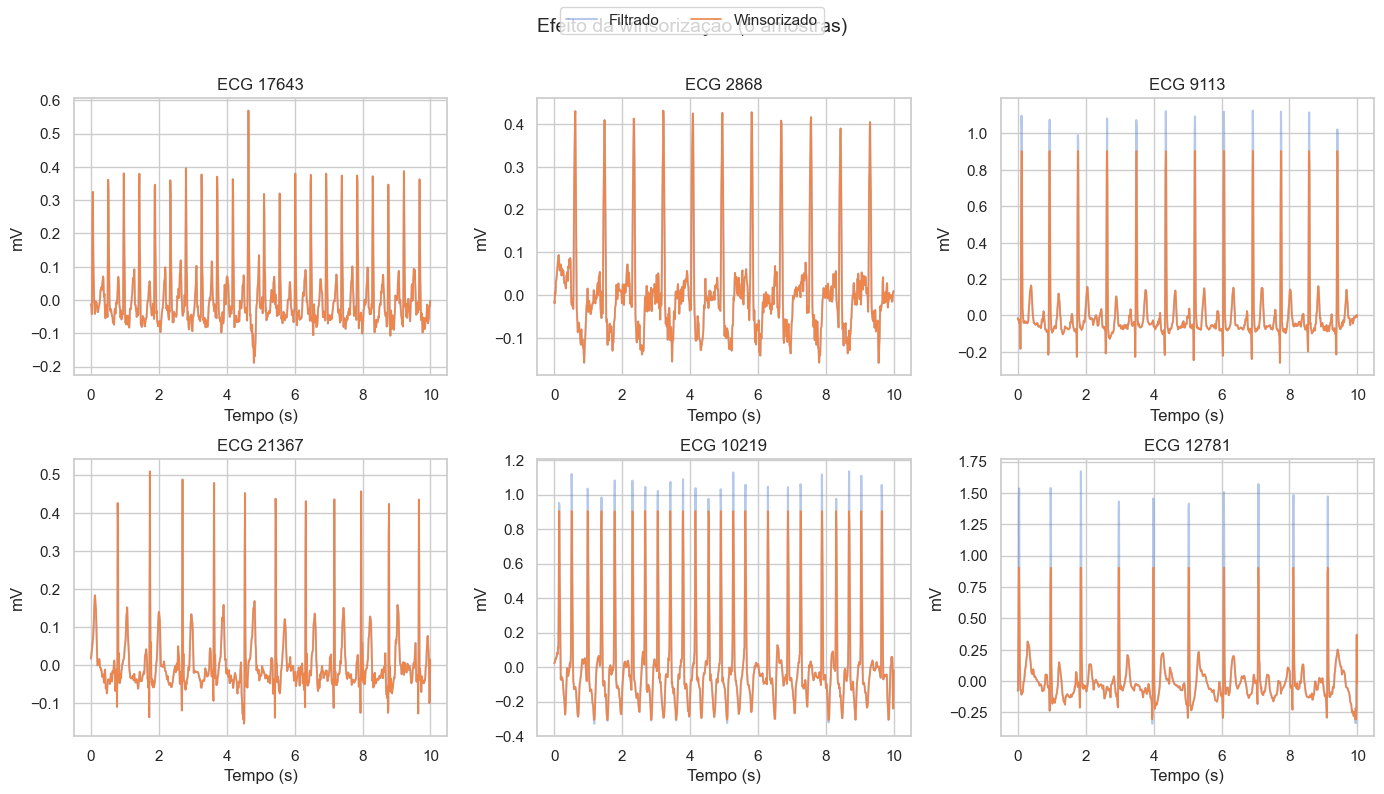

In [14]:
# Seleciona 6 amostras para winsorizar e demonstrar a diferença entre os sinais
amostras = df.sample(6, random_state=31).index

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eid in enumerate(amostras):
    ax = axes[i]
    
    raw = load_ecg_raw(eid)
    filt = preprocess_signal(raw)
    wins = winsorizar(filt, limites_treino)
    
    t = np.arange(len(raw)) / FS
    
    ax.plot(t, filt[:, 0], alpha=0.4, label='Filtrado')
    ax.plot(t, wins[:, 0], linewidth=1.2, label='Winsorizado')
    
    ax.set_title(f'ECG {eid}')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('mV')

# Legenda global
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)

plt.suptitle('Efeito da winsorização (6 amostras)', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.88)

plt.savefig(FIGS_DIR / 'winsorizacao.png', dpi=150)
plt.show()

### 3.5 Relação com Distorções Morfológicas (hosSQI)

A métrica *hosSQI* (Higher-Order Statistics Signal Quality Index) utilizada neste trabalho é baseada em uma combinação de estatísticas de ordem superior, incorporando simultaneamente:

- **assimetria (skewness)**  
- **curtose (kurtosis)**  

Essa formulação torna a métrica sensível a:

- distribuições assimétricas  
- presença de caudas pesadas  
- ocorrência de picos abruptos no sinal  

No contexto do Entregável 2, valores **baixos de hosSQI** (<0.5) foram associados a sinais com **distorções morfológicas relevantes**, indicando:

- perda de estrutura característica (ondas P-QRS-T)  
- irregularidades no formato do sinal  
- degradação da qualidade global  

Por outro lado, valores elevados de *hosSQI* não são, por si só, tratados como problemáticos, podendo refletir tanto:

- sinais com morfologia bem definida  
- quanto presença de picos impulsivos ou artefatos localizados  

Assim, a interpretação da métrica deve ser contextual.

---

Nesse cenário, é importante destacar que:

> Distorções morfológicas não são diretamente corrigíveis por filtragem clássica nem por técnicas simples de ajuste de amplitude

No entanto, a winsorização contribui **indiretamente** para a estabilização desses casos ao:

- limitar valores extremos associados a impulsos anômalos  
- reduzir a influência de caudas pesadas na distribuição  
- estabilizar estatísticas de ordem superior (especialmente curtose)  

Com isso, mesmo sem reconstruir a forma do sinal, a abordagem:

- reduz a variabilidade indesejada  
- melhora a robustez de métricas estatísticas  
- aumenta a consistência entre registros  

Assim:

> A estratégia adotada não busca corrigir a morfologia do sinal, mas reduzir o impacto estatístico de suas distorções

---

### 3.6 Limitações

A abordagem baseada em winsorização apresenta limitações inerentes:

- Não corrige distorções morfológicas estruturais  
- Pode atenuar eventos fisiológicos raros de alta amplitude  
- Depende da escolha adequada dos percentis  

Além disso, a técnica não distingue explicitamente entre:

- outliers associados a artefatos  
- variações fisiológicas legítimas do sinal  

Portanto, sua aplicação deve ser interpretada como um mecanismo de **controle estatístico**, e não de correção semântica do sinal.

---

### Síntese da Seção

A combinação de filtragem (Seção 2) e winsorização permite atuar em dois níveis complementares:

- **Domínio da frequência** → remoção de ruído estrutural  
- **Domínio da amplitude** → controle de valores extremos  

Essa integração resulta em sinais mais estáveis, com menor variabilidade espúria, tornando-os mais adequados para análise estatística e modelagem subsequente.

---

## Seção 4 — Processamento em Lote e Salvamento

Após a definição e validação das etapas de pré-processamento (filtragem e winsorização), esta seção realiza a aplicação da pipeline em todo o conjunto de dados.

O objetivo é gerar uma versão padronizada e limpa dos sinais, adequada para etapas subsequentes de análise e modelagem.

### 4.1 Salvamento dos Parâmetros da Pipeline

Para garantir reprodutibilidade, todos os parâmetros utilizados na pipeline são armazenados em disco.

Isso inclui:

- coeficientes dos filtros digitais  
- limites de winsorização  
- configurações gerais do processamento  

Esse procedimento permite:

- reaplicar o pipeline em novos dados  
- auditar o processamento realizado  
- garantir consistência entre diferentes execuções  

In [15]:
# Salvamento dos parâmetros da pipeline

params_pipeline = {
    'bandpass_filters': get_bandpass_filters(FS),
    'winsorize_bounds': limites_treino,
    'config': {
        'fs': FS,
        'hp_fc': 0.5,
        'lp_fc': 40,
        'butter_order': 5,
        'nota_tecnica': 'notch 50Hz dispensado via anti-aliasing prévio'
    }
}

params_path = OUT_DIR / 'preprocessing_params.pkl'
joblib.dump(params_pipeline, params_path)

display(Markdown(f"""
**Parâmetros da pipeline salvos em:**
`{params_path.name}`
"""))


**Parâmetros da pipeline salvos em:**
`preprocessing_params.pkl`


### 4.2 Processamento em Lote

A pipeline completa é aplicada a todos os registros selecionados (classes G, A e P), seguindo as etapas:

1. Carregamento do sinal bruto  
2. Filtragem (passa-alta + passa-baixa)  
3. Winsorização por derivação  
4. Armazenamento do resultado  

Os sinais processados são armazenados em um array NumPy tridimensional, com dimensões:

- número de registros  
- número de amostras por sinal  
- número de derivações 

In [16]:
# Processamento em lote de todos os registros

total = len(df)

sinais_finais = np.zeros((total, 1000, N_LEADS), dtype=np.float32)
ids_ordem = []

display(Markdown(f"Processando **{total}** registros... (pode levar alguns minutos)"))

for i, eid in enumerate(tqdm(df.index, desc='Processando sinais')):
    sig_raw = load_ecg_raw(eid)
    
    # Pipeline completa
    sig_proc = preprocess_signal(sig_raw)
    sig_limpo = winsorizar(sig_proc, limites_treino)
    
    sinais_finais[i] = sig_limpo.astype(np.float32)
    ids_ordem.append(eid)

Processando **19840** registros... (pode levar alguns minutos)

Processando sinais: 100%|██████████| 19840/19840 [04:48<00:00, 68.89it/s]


---

## Seção 5 — Validação Estatística: Antes vs. Depois

Esta seção tem como objetivo avaliar quantitativamente o impacto da pipeline de pré-processamento sobre os sinais de ECG.

Diferentemente das etapas anteriores, que focaram na implementação e demonstração qualitativa, aqui são utilizadas métricas estatísticas para verificar:

- se houve alteração significativa nos sinais  
- a magnitude dessa alteração  
- como essa alteração varia conforme o tipo de artefato presente  

### 5.1 Estratégia de Avaliação

A validação foi conduzida por meio de comparação pareada entre:

- sinais originais (antes do processamento)  
- sinais após aplicação completa da pipeline (filtragem + winsorização)  

Para isso, foram utilizadas duas métricas globais:

- **RMS (Root Mean Square)** → mede a magnitude média do sinal  
- **Energia total** → soma dos quadrados das amplitudes  

Essas métricas permitem avaliar mudanças estruturais no sinal, especialmente relacionadas à presença de ruído.

### 5.2 Agrupamento por Tipo de Artefato

Os sinais foram agrupados com base nas anotações de qualidade fornecidas pelo dataset, que indicam a presença de artefatos específicos:

- drift de linha de base  
- ruído estático  
- ruído do tipo burst  
- problemas de eletrodo  

Além disso, foi considerado um grupo adicional:

- **Sinais sem artefatos anotados**

Esse grupo representa registros nos quais não foram identificadas degradações explícitas pelo dataset.

> A ausência de anotações não implica necessariamente ausência de ruído ou qualidade ideal do sinal.

Os grupos não são mutuamente exclusivos, podendo um mesmo sinal apresentar múltiplos tipos de artefato.

### 5.3 Testes Estatísticos

Para cada grupo de sinais, foi realizada uma comparação pareada antes vs. depois utilizando:

- **Teste de Wilcoxon signed-rank**  
- **Cohen’s d (effect size)**  

O teste de *Wilcoxon verifica se há diferença* estatisticamente significativa entre os sinais antes e depois do processamento, sem assumir normalidade dos dados.

Já o *Cohen’s d quantifica a magnitude dessa diferença*, permitindo interpretar sua relevância prática.

### 5.4 Interpretação dos Resultados

Os resultados devem ser interpretados de forma conjunta:

- **p-valor (Wilcoxon):**
  - p < 0.05 → diferença significativa  
  - p ≥ 0.05 → sem evidência de diferença  

- **Cohen’s d:**

| Valor de d | Interpretação |
|---|---|
| < 0.2 | Trivial |
| 0.2 – 0.5 | Pequeno |
| 0.5 – 0.8 | Médio |
| > 0.8 | Grande |

### 5.5 Expectativas Teóricas

Espera-se que:

- Grupos com artefatos (baseline, ruído, etc.) apresentem:
  - diferenças significativas  
  - valores elevados de Cohen’s d  

- O grupo sem artefatos anotados apresente:
  - alterações reduzidas  
  - valores de d próximos de zero  

Esse comportamento indicaria que a pipeline atua de forma seletiva, corrigindo sinais degradados e preservando sinais sem degradação explícita.

In [18]:
# Validação Estatística — Antes vs Depois

# ============================================================
# 1. Conversão das colunas de artefato (string → flag)
# ============================================================

def has_issue(x):
    """
    Retorna 1 se houver indicação de artefato (string não vazia),
    0 caso contrário.
    """
    if pd.isna(x):
        return 0
    
    x_str = str(x).strip()
    
    # Remove espaços e vírgulas residuais
    x_str = x_str.replace(',', '').strip()
    
    return int(len(x_str) > 0)


# Criando flags binárias
df['baseline_flag'] = df['baseline_drift'].apply(has_issue)
df['static_noise_flag'] = df['static_noise'].apply(has_issue)
df['burst_noise_flag'] = df['burst_noise'].apply(has_issue)
df['electrode_flag'] = df['electrodes_problems'].apply(has_issue)


# ============================================================
# 2. Definição dos grupos
# ============================================================

grupos = {
    'Baseline Drift': df[df['baseline_flag'] == 1].index,
    'Ruído Estático': df[df['static_noise_flag'] == 1].index,
    'Ruído Burst': df[df['burst_noise_flag'] == 1].index,
    'Problema de Eletrodo': df[df['electrode_flag'] == 1].index
}

# Grupo sem artefatos anotados
cols_flags = ['baseline_flag', 'static_noise_flag', 'burst_noise_flag', 'electrode_flag']

grupo_sem_artefato = df[(df[cols_flags].sum(axis=1) == 0)].index
grupos['Sem artefatos anotados'] = grupo_sem_artefato

# Remover grupos vazios
grupos = {k: v for k, v in grupos.items() if len(v) > 0}


# Visualização inicial
display(Markdown(f"""
### Grupos de validação definidos

{chr(10).join([f"- **{k}**: {len(v)} registros" for k, v in grupos.items()])}

> Obs.: os grupos não são mutuamente exclusivos.
"""))


# ============================================================
# 3. Função de comparação estatística
# ============================================================

def comparar_antes_depois(grupo_ids, nome_grupo):
    antes_rms, depois_rms = [], []
    antes_energy, depois_energy = [], []

    for eid in tqdm(grupo_ids, desc=nome_grupo, leave=False):
        raw = load_ecg_raw(eid)
        clean = winsorizar(preprocess_signal(raw), limites_treino)

        # RMS global
        rms_raw = np.sum(np.sqrt(np.mean(raw**2, axis=0)))
        rms_clean = np.sum(np.sqrt(np.mean(clean**2, axis=0)))

        # Energia total
        energy_raw = np.sum(raw**2)
        energy_clean = np.sum(clean**2)

        antes_rms.append(rms_raw)
        depois_rms.append(rms_clean)
        antes_energy.append(energy_raw)
        depois_energy.append(energy_clean)

    resultados = []

    for metrica, a, d in [
        ('RMS global', antes_rms, depois_rms),
        ('Energia total', antes_energy, depois_energy)
    ]:
        a, d = np.array(a), np.array(d)
        diff = a - d

        # Cohen's d (pareado)
        cohen_d = np.mean(diff) / (np.std(diff) + 1e-10)

        # Wilcoxon
        try:
            _, p = stats.wilcoxon(a, d)
        except ValueError:
            p = np.nan

        resultados.append({
            'Grupo': nome_grupo,
            'Métrica': metrica,
            'N': len(a),
            'Média antes': np.mean(a),
            'Média depois': np.mean(d),
            'Δ média': np.mean(d - a),
            'Cohen d': cohen_d,
            'p-valor': "< 0.001" if (not np.isnan(p) and p < 0.001)
                       else round(p, 4) if not np.isnan(p) else 'NA'
        })

    return resultados


# ============================================================
# 4. Execução da validação
# ============================================================

todos_resultados = []

for nome, ids in grupos.items():
    if len(ids) > 10:  # evita grupos pequenos demais
        todos_resultados.extend(comparar_antes_depois(ids, nome))

df_validacao = pd.DataFrame(todos_resultados)
df_validacao = df_validacao.set_index(['Grupo', 'Métrica']).round(4)

display(df_validacao)



### Grupos de validação definidos

- **Baseline Drift**: 1277 registros
- **Ruído Estático**: 3039 registros
- **Ruído Burst**: 542 registros
- **Problema de Eletrodo**: 25 registros
- **Sem artefatos anotados**: 15365 registros

> Obs.: os grupos não são mutuamente exclusivos.


N  Média antes  Média depois  \
Grupo                  Métrica                                           
Baseline Drift         RMS global      1277       2.6554        1.9730   
                       Energia total   1277    1086.6465      433.2857   
Ruído Estático         RMS global      3039       2.1398        1.9278   
                       Energia total   3039     533.6661      402.9865   
Ruído Burst            RMS global       542       2.4504        2.0629   
                       Energia total    542     896.1044      475.4632   
Problema de Eletrodo   RMS global        25       3.0563        2.4238   
                       Energia total     25    1378.9883      702.5012   
Sem artefatos anotados RMS global     15365       2.2358        1.9609   
                       Energia total  15365     605.3218      423.8068   

                                       Δ média  Cohen d  p-valor  
Grupo                  Métrica                                    
Baseline Drift         RMS global      -0.6824   1.0564  < 0.001  
                       Energia total -653.3608   0.3309  < 0.001  
Ruído Estático         RMS global      -0.2120   0.6406  < 0.001  
                       Energia total -130.6796   0.3569  < 0.001  
Ruído Burst            RMS global      -0.3876   0.6399  < 0.001  
                       Energia total -420.6412   0.3341  < 0.001  
Problema de Eletrodo   RMS global      -0.6325   0.7717  < 0.001  
                       Energia total -676.4871   0.4972  < 0.001  
Sem artefatos anotados RMS global      -0.2749   0.7114  < 0.001  
                       Energia total -181.5150   0.1884  < 0.001

**Análise dos Resultados Estatísticos**

Os resultados obtidos evidenciam que a aplicação da pipeline de pré-processamento promoveu alterações estatisticamente significativas em todos os grupos analisados.

Em todos os casos, o teste de Wilcoxon apresentou:

- **p-valor < 0.001**

indicando rejeição consistente da hipótese nula de igualdade entre os sinais antes e depois do processamento.

Isso demonstra que a pipeline produz modificações sistemáticas nas propriedades dos sinais.

#### Magnitude das Alterações (Cohen’s d)

A análise do tamanho de efeito revela diferenças importantes entre os grupos.

##### Grupos com artefatos explícitos

Os grupos associados a artefatos apresentaram, em geral, **efeitos de magnitude moderada a grande**:

- **Baseline Drift**
  - RMS: d ≈ 1.06 (grande)
  - Forte redução da amplitude média do sinal

- **Ruído Estático**
  - RMS: d ≈ 0.64 (médio)
  - Redução consistente de componentes ruidosas

- **Ruído Burst**
  - RMS: d ≈ 0.64 (médio)
  - Atenuação de eventos impulsivos

- **Problemas de Eletrodo**
  - RMS: d ≈ 0.77 (médio–alto)
  - Impacto significativo, apesar do baixo número de amostras

Esses resultados indicam que a pipeline atua de forma eficaz na redução de artefatos conhecidos.

##### Grupo sem artefatos anotados

Para o grupo de sinais sem artefatos anotados, observa-se:

- RMS: d ≈ 0.71 (médio)
- Energia: d ≈ 0.19 (pequeno)

Apesar da ausência de anotações explícitas, ainda há alterações estatisticamente significativas.

Isso sugere que:

- existem componentes de ruído não identificados nas anotações do dataset  
- a pipeline atua também sobre variações sutis do sinal  

No entanto, a menor magnitude observada na energia indica que:

> a alteração global do sinal é mais limitada em comparação com grupos degradados


#### Redução de Energia

Em todos os grupos, observa-se:

- **Δ média negativa para RMS e energia**

indicando redução sistemática da magnitude do sinal após o processamento.

Esse comportamento é consistente com:

- remoção de componentes de baixa frequência (drift)  
- atenuação de ruído de alta frequência  
- limitação de valores extremos via winsorização  


#### Interpretação Global

A combinação dos resultados permite afirmar que:

- a pipeline promove **alterações estatisticamente significativas** em todos os grupos  
- a **magnitude dessas alterações depende do tipo de artefato presente**  
- sinais com degradação explícita sofrem **maior impacto**, como esperado  
- sinais sem artefatos anotados também são modificados, porém de forma mais controlada  

Esse comportamento indica que a pipeline atua de forma consistente na redução de ruído, embora não seja completamente seletiva.


#### Considerações Críticas

Alguns pontos devem ser destacados:

- A significância estatística elevada é influenciada pelo grande tamanho amostral  
- Métricas como RMS e energia não capturam diretamente aspectos morfológicos  
- Redução de energia não implica necessariamente melhoria clínica  

Dessa forma:

> Os resultados indicam modificação estrutural do sinal, mas não são suficientes, isoladamente, para afirmar melhoria de qualidade.

Por esse motivo, torna-se necessária uma análise complementar baseada em métricas de qualidade (SQI), apresentada na sequência.

### 5.6 Reavaliação da Qualidade dos Sinais (SQI)

Após a aplicação completa da pipeline de pré-processamento — incluindo filtragem digital (Seção 2) e winsorização (Seção 3) — é necessário avaliar seu impacto na **qualidade global dos sinais**, e não apenas em métricas isoladas.

Para isso, realizamos a reavaliação das métricas de SQI sobre os sinais processados, mantendo **exatamente os mesmos critérios e thresholds definidos no Entregável 2**.

Diferentemente da etapa anterior, as métricas do estado "antes" não são recalculadas, sendo diretamente reutilizadas a partir do dataset já enriquecido com SQI (`ptbxl_com_sqi.csv`). Isso garante:

- Consistência metodológica entre os entregáveis  
- Reprodutibilidade dos resultados  
- Eficiência computacional (evitando recomputações desnecessárias)  


### Estratégia de avaliação

A análise é conduzida da seguinte forma:

1. Utiliza-se o SQI previamente calculado (estado "antes")  
2. Cada sinal é processado pela pipeline:
   - filtragem digital  
   - winsorização  
3. As métricas de SQI são recalculadas apenas para o sinal processado  
4. Os sinais são novamente classificados em:
   - **G (Excelente)**  
   - **A (Aceitável)**  
   - **P (Processável)**  
   - **U (Inaceitável)**  


### Objetivo da análise

A comparação entre as classificações antes e depois permite avaliar:

- **Ganho de qualidade** (ex: P $\rightarrow$ A, A $\rightarrow$ G)  
- **Estabilidade da pipeline** (ausência de degradação em sinais bons)  
- **Capacidade de recuperação de sinais degradados**  


### Interpretação esperada

Espera-se observar:

- Redução da proporção de sinais classificados como **P**  
- Aumento das classes **A** e potencialmente **G**  
- Baixa incidência de degradação (ex: A $\rightarrow$ P ou G $\rightarrow$ A)  

Esses resultados indicam que a pipeline:

> Atua de forma seletiva, corrigindo sinais degradados sem comprometer a integridade de sinais já adequados.

In [19]:
# Recalculo de métricas SQI pós limpeza dos dados, com salvamento do cálculo anterior (feito no entregável 2)

df_sqi_before = df.copy()
results_after = []

display(Markdown("Calculando SQI após a aplicação da pipeline..."))

for eid in tqdm(df.index, desc='Reavaliando SQI'):

    raw = load_ecg_raw(eid)

    clean = winsorizar(
        preprocess_signal(raw),
        limites_treino
    )

    sqi_after = compute_all_sqi(clean, fs=FS)
    sqi_after['ecg_id'] = eid

    results_after.append(sqi_after)

df_sqi_after = pd.DataFrame(results_after).set_index('ecg_id')

display(Markdown("Reavaliação de SQI concluída."))

Calculando SQI após a aplicação da pipeline...

Reavaliando SQI: 100%|██████████| 19840/19840 [15:54<00:00, 20.79it/s]


Reavaliação de SQI concluída.

In [20]:
# Reclassificação da qualidade de sinais SQI

df_sqi_after['quality_class'] = classify_sqi(df_sqi_after)

In [21]:
# Comparação da distribuição das classes SQI - Antes vs Depois 

ordem = ['G', 'A', 'P', 'U']

dist_before = df_sqi_before['quality_class'].value_counts().reindex(ordem)
dist_after  = df_sqi_after['quality_class'].value_counts().reindex(ordem)

pct_before = (dist_before / dist_before.sum()) * 100
pct_after  = (dist_after / dist_after.sum()) * 100

df_compare = pd.DataFrame({
    'Antes (Qtd)': dist_before,
    'Antes (%)': pct_before.round(2),
    'Depois (Qtd)': dist_after,
    'Depois (%)': pct_after.round(2)
})

display(Markdown("### Distribuição das Classes — Antes vs Depois"))
display(df_compare)

### Distribuição das Classes — Antes vs Depois

,Antes (Qtd),Antes (%),Depois (Qtd),Depois (%)
quality_class,,,,
G,NaN,NaN,2270,11.44
A,16475.0,83.04,15474,77.99
P,3365.0,16.96,377,1.90
U,NaN,NaN,1719,8.66


In [22]:
# Matriz de Transição de Classes

matriz_transicao = pd.crosstab(
    df_sqi_before['quality_class'],
    df_sqi_after['quality_class'],
    rownames=['Antes'],
    colnames=['Depois']
)

display(Markdown("### Matriz de Transição de Classes"))
display(matriz_transicao)

### Matriz de Transição de Classes

Depois,A,G,P,U
Antes,,,,
A,13102,2104,193,1076
P,2372,166,184,643


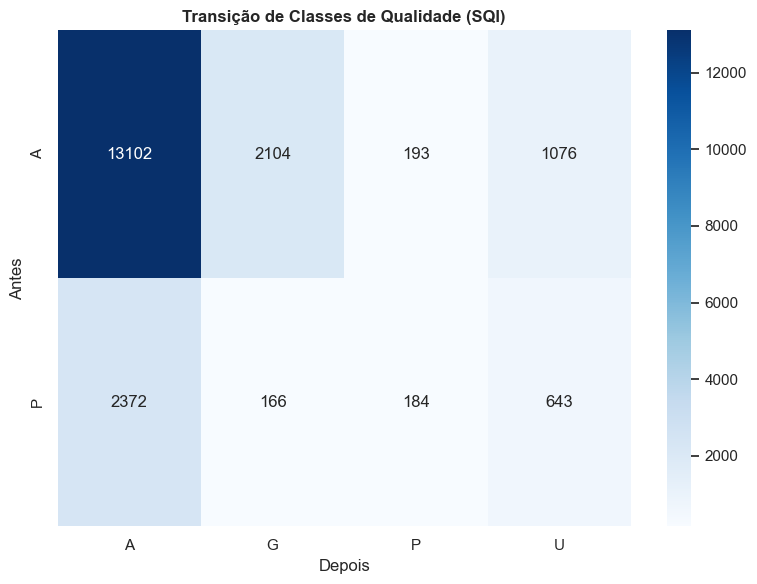

In [23]:
# Heatmap da matriz de transição de classes

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    matriz_transicao,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax
)

ax.set_title('Transição de Classes de Qualidade (SQI)', fontweight='bold')

plt.tight_layout()

fig.savefig(
    os.path.join(FIGS_DIR, 'transicao_classes_sqi.png'),
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**Comentários da Subseção 5.6:**

A reavaliação da qualidade dos sinais após a aplicação da pipeline de pré-processamento revelou mudanças expressivas na distribuição das classes de qualidade, evidenciando tanto a eficácia quanto o caráter seletivo do método adotado. Observa-se, inicialmente, uma redução substancial da classe **P (Processável)**, que passa de aproximadamente 17% para menos de 2% do dataset. Essa queda acentuada indica que a pipeline foi capaz de corrigir uma parcela significativa de sinais que anteriormente apresentavam degradações tratáveis, promovendo-os majoritariamente à classe **A (Aceitável)**. Paralelamente, verifica-se o surgimento de uma quantidade relevante de sinais classificados como **G (Excelente)**, inexistente na avaliação inicial, o que sugere que a limpeza aplicada não apenas removeu artefatos, mas também permitiu que sinais previamente “mascarados” por ruído atingissem um patamar superior de qualidade.

Ao mesmo tempo, a análise evidencia um aumento na proporção de sinais classificados como **U (Inaceitável)** após o processamento. Embora, à primeira vista, esse comportamento possa parecer indesejável, ele deve ser interpretado com cautela. A pipeline, ao reduzir componentes de ruído e estabilizar o sinal, também tende a expor de forma mais clara distorções estruturais e problemas morfológicos que anteriormente poderiam estar encobertos. Assim, parte dos sinais que antes eram classificados como aceitáveis ou processáveis passa a ser corretamente identificada como de baixa qualidade intrínseca. Esse fenômeno reforça a ideia de que o pré-processamento não atua apenas como um mecanismo de melhoria, mas também como um processo de **refinamento da avaliação**, tornando os critérios de qualidade mais sensíveis e fiéis à condição real do sinal.

A matriz de transição entre as classificações antes e depois do processamento corrobora essa interpretação. A maior parte dos sinais inicialmente classificados como **A** permanece na mesma categoria, indicando que a pipeline preserva a integridade de sinais já adequados, sem introduzir distorções relevantes. Por outro lado, há um volume significativo de transições positivas, como **P → A** e **A → G**, demonstrando a capacidade do método em recuperar sinais degradados e aprimorar aqueles já razoavelmente limpos. Em contrapartida, também são observadas transições para **U**, especialmente a partir de sinais previamente classificados como **A** ou **P**, o que sugere uma reavaliação mais rigorosa após a remoção de ruído.

De forma geral, os resultados indicam que a pipeline atua em dois níveis complementares: por um lado, promove a melhoria efetiva de sinais com degradações tratáveis; por outro, aumenta o poder discriminativo das métricas de qualidade, permitindo uma separação mais clara entre sinais recuperáveis e sinais estruturalmente comprometidos. Dessa maneira, a etapa de pré-processamento não deve ser interpretada apenas como um mecanismo de limpeza, mas como um componente fundamental para a **qualificação confiável dos dados**, contribuindo diretamente para a robustez das análises subsequentes.

---


## Seção 6 — Síntese e Conexão

Ao longo deste entregável, foi **desenvolvida uma pipeline completa de limpeza de sinais de ECG**, com o objetivo de melhorar sua qualidade e garantir maior confiabilidade para as etapas posteriores de análise. Partindo de um conjunto de dados previamente avaliado por métricas de qualidade (SQI), foram aplicadas **técnicas complementares que atuam tanto no domínio da frequência quanto no domínio da amplitude**, buscando reduzir artefatos sem comprometer a morfologia fisiológica dos sinais.

A etapa de **filtragem digital** demonstrou-se eficaz na remoção de componentes indesejadas, como o drift de baseline e o ruído de alta frequência. A utilização de filtros Butterworth passa-alta (0.5 Hz) e passa-baixa (40 Hz), ambos de quinta ordem, **permitiu estabilizar a linha de base e preservar a banda de interesse do ECG**. As análises no domínio do tempo e da frequência confirmaram que a estrutura das ondas P-QRS-T foi mantida, ao mesmo tempo em que houve atenuação consistente de componentes espúrias fora da faixa fisiológica relevante.

Em seguida, a **aplicação da winsorização**, com limites definidos a partir do conjunto de treino, possibilitou o controle de valores extremos sem introduzir distorções abruptas. Essa etapa **atuou principalmente na mitigação de outliers associados a artefatos impulsivos e saturações**, contribuindo para a estabilização das propriedades estatísticas dos sinais. A definição dos limites com base exclusivamente nos dados de treino garantiu a ausência de vazamento de informação (data leakage), mantendo a integridade metodológica do processo.

A **validação da pipeline** foi conduzida de forma abrangente, **combinando testes estatísticos e reavaliação das métricas de qualidade**. Os testes de Wilcoxon pareado e a análise do tamanho de efeito (Cohen’s d) evidenciaram reduções significativas de energia e amplitude em grupos com ruído conhecido, enquanto sinais mais estáveis apresentaram alterações moderadas, indicando que a pipeline atua de maneira seletiva. Complementarmente, a reclassificação via SQI revelou uma redução expressiva da classe “Processável” e o surgimento de sinais classificados como “Excelente”, ao mesmo tempo em que alguns registros anteriormente aceitos no Entregável 2 passaram a ser identificados como “Inaceitáveis”, sugerindo uma avaliação mais rigorosa após a remoção de ruídos mascaradores.

De forma integrada, **os resultados indicam que a pipeline não apenas melhora a qualidade dos sinais, mas também aumenta a capacidade de discriminação entre diferentes níveis de qualidade, tornando o dataset mais consistente e confiável para análise**. A combinação entre filtragem no domínio da frequência e controle de outliers no domínio da amplitude mostrou-se eficaz para lidar com diferentes tipos de artefatos, preservando as características fisiológicas essenciais do ECG.

Com isso, o dataset processado encontra-se preparado para as próximas etapas do pipeline analítico. No Entregável 5, os sinais limpos serão segmentados em janelas temporais, permitindo transformar registros contínuos em múltiplas amostras menores e mais adequadas para modelagem. Essa etapa será fundamental para capturar variações locais do sinal e viabilizar a extração de features, além de possibilitar estratégias mais robustas de aprendizado de máquina. A qualidade garantida neste entregável estabelece, portanto, a base necessária para que a segmentação e as análises subsequentes sejam realizadas de forma consistente e confiável.

In [28]:
# Salvamento final da pipeline (separando bons e ruins)

display(Markdown("## Salvando datasets finais (bons vs ruins)..."))

# Caminhos
npy_path_bons = OUT_DIR / 'sinais_bons_100hz.npy'
npy_path_ruins = OUT_DIR / 'sinais_ruins_100hz.npy'

csv_path_bons = OUT_DIR / 'ptbxl_bons_com_sqi.csv'
csv_path_ruins = OUT_DIR / 'ptbxl_ruins_com_sqi.csv'

params_path = OUT_DIR / 'preprocessing_params.pkl'

# -------------------------
# 1. Montar DataFrame final
# -------------------------
df_final = df.copy()
df_final = df_final.loc[ids_ordem]

# Guardar classificação original
df_final['quality_class_original'] = df['quality_class']

# Nova classificação
df_final['quality_class'] = df_sqi_after['quality_class']

# Adicionar métricas SQI recalculadas
for col in df_sqi_after.columns:
    df_final[f'{col}_after'] = df_sqi_after[col]

# -------------------------
# 2. Separar bons e ruins
# -------------------------
mask_bons = df_final['quality_class'].isin(['G', 'A'])
mask_ruins = df_final['quality_class'].isin(['P', 'U'])

df_bons = df_final[mask_bons]
df_ruins = df_final[mask_ruins]

# Índices correspondentes nos sinais
idx_bons = np.where(mask_bons)[0]
idx_ruins = np.where(mask_ruins)[0]

sinais_bons = sinais_finais[idx_bons]
sinais_ruins = sinais_finais[idx_ruins]

# -------------------------
# 3. Salvar sinais
# -------------------------
for path in [npy_path_bons, npy_path_ruins]:
    if path.exists():
        try:
            path.unlink()
        except Exception as e:
            print(f"Aviso ao remover arquivo antigo: {e}")

np.save(str(npy_path_bons), sinais_bons)
np.save(str(npy_path_ruins), sinais_ruins)

# -------------------------
# 4. Salvar metadados
# -------------------------
df_bons.to_csv(csv_path_bons)
df_ruins.to_csv(csv_path_ruins)

# -------------------------
# 5. Salvar parâmetros
# -------------------------
params_pipeline = {
    'bandpass_filters': get_bandpass_filters(fs=FS),
    'winsorize_bounds': limites_treino,
    'config': {
        'fs': FS,
        'hp_fc': 0.5,
        'lp_fc': 40,
        'butter_order': 4
    }
}

joblib.dump(params_pipeline, params_path)

# -------------------------
# 6. Resumo
# -------------------------
tam_bons = npy_path_bons.stat().st_size / (1024**3)
tam_ruins = npy_path_ruins.stat().st_size / (1024**3)

display(Markdown(f"""
### Exportação final concluída

#### Sinais bons (G + A)
- Arquivo: `sinais_bons_100hz.npy`
- Shape: `{sinais_bons.shape}`
- Tamanho: **{tam_bons:.2f} GB**
- Registros: **{len(df_bons)}**

#### Sinais ruins (P + U)
- Arquivo: `sinais_ruins_100hz.npy`
- Shape: `{sinais_ruins.shape}`
- Tamanho: **{tam_ruins:.2f} GB**
- Registros: **{len(df_ruins)}**

#### Metadados
- Bons: `ptbxl_bons_com_sqi.csv`
- Ruins: `ptbxl_ruins_com_sqi.csv`

#### Parâmetros da pipeline
- `preprocessing_params.pkl`

---
"""))

## Salvando datasets finais (bons vs ruins)...


### Exportação final concluída

#### Sinais bons (G + A)
- Arquivo: `sinais_bons_100hz.npy`
- Shape: `(17744, 1000, 12)`
- Tamanho: **0.79 GB**
- Registros: **17744**

#### Sinais ruins (P + U)
- Arquivo: `sinais_ruins_100hz.npy`
- Shape: `(2096, 1000, 12)`
- Tamanho: **0.09 GB**
- Registros: **2096**

#### Metadados
- Bons: `ptbxl_bons_com_sqi.csv`
- Ruins: `ptbxl_ruins_com_sqi.csv`

#### Parâmetros da pipeline
- `preprocessing_params.pkl`

---
